# EDA — MIND Small Dataset (News Recommendation)

Dataset: Microsoft News Dataset (MIND Small)  
Mục tiêu: Hiểu cấu trúc dữ liệu trước khi xây dựng model Content-Based Filtering

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import json
import ast
from collections import Counter
from pathlib import Path

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
sns.set_theme(style='whitegrid')

TRAIN_DIR = Path('data/raw/MINDsmall_train')
DEV_DIR   = Path('data/raw/MINDsmall_dev')

NEWS_COLS = ['news_id', 'category', 'subcategory', 'title', 'abstract',
             'url', 'title_entities', 'abstract_entities']
BEH_COLS  = ['imp_id', 'user_id', 'time', 'history', 'impressions']

train_news = pd.read_csv(TRAIN_DIR / 'news.tsv', sep='\t', header=None, names=NEWS_COLS)
dev_news   = pd.read_csv(DEV_DIR   / 'news.tsv', sep='\t', header=None, names=NEWS_COLS)

train_beh  = pd.read_csv(TRAIN_DIR / 'behaviors.tsv', sep='\t', header=None, names=BEH_COLS)
dev_beh    = pd.read_csv(DEV_DIR   / 'behaviors.tsv', sep='\t', header=None, names=BEH_COLS)

print(f"Train news : {train_news.shape}  |  Dev news : {dev_news.shape}")
print(f"Train beh  : {train_beh.shape}   |  Dev beh  : {dev_beh.shape}")

Train news : (51282, 8)  |  Dev news : (42416, 8)
Train beh  : (156965, 5)   |  Dev beh  : (73152, 5)


---
## 1. News — Tổng quan

In [3]:
print("=== Train News - 5 dòng đầu ===")
train_news.head()

=== Train News - 5 dòng đầu ===


,news_id,category,subcategory,title,abstract,url,title_entities,abstract_entities
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[]
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik..."
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId..."
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",https://assets.msn.com/labs/mind/AACk2N6.html,[],"[{""Label"": ""National Basketball Association"", ..."
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re...",https://assets.msn.com/labs/mind/AAAKEkt.html,"[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI...","[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI..."


In [4]:
print("=== Missing values (Train News) ===")
missing = train_news.isnull().sum()
missing_pct = (missing / len(train_news) * 100).round(2)
pd.DataFrame({'count': missing, 'pct (%)': missing_pct})

=== Missing values (Train News) ===


,count,pct (%)
news_id,0,0.00
category,0,0.00
subcategory,0,0.00
title,0,0.00
abstract,2666,5.20
url,0,0.00
title_entities,3,0.01
abstract_entities,4,0.01


---
## 2. News — Phân phối Category & Subcategory

C:\Users\admin\AppData\Local\Temp\ipykernel_3280\3232657332.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_counts.values, y=cat_counts.index, ax=axes[0], palette='Blues_r')
C:\Users\admin\AppData\Local\Temp\ipykernel_3280\3232657332.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sub_counts.values, y=sub_counts.index, ax=axes[1], palette='Greens_r')


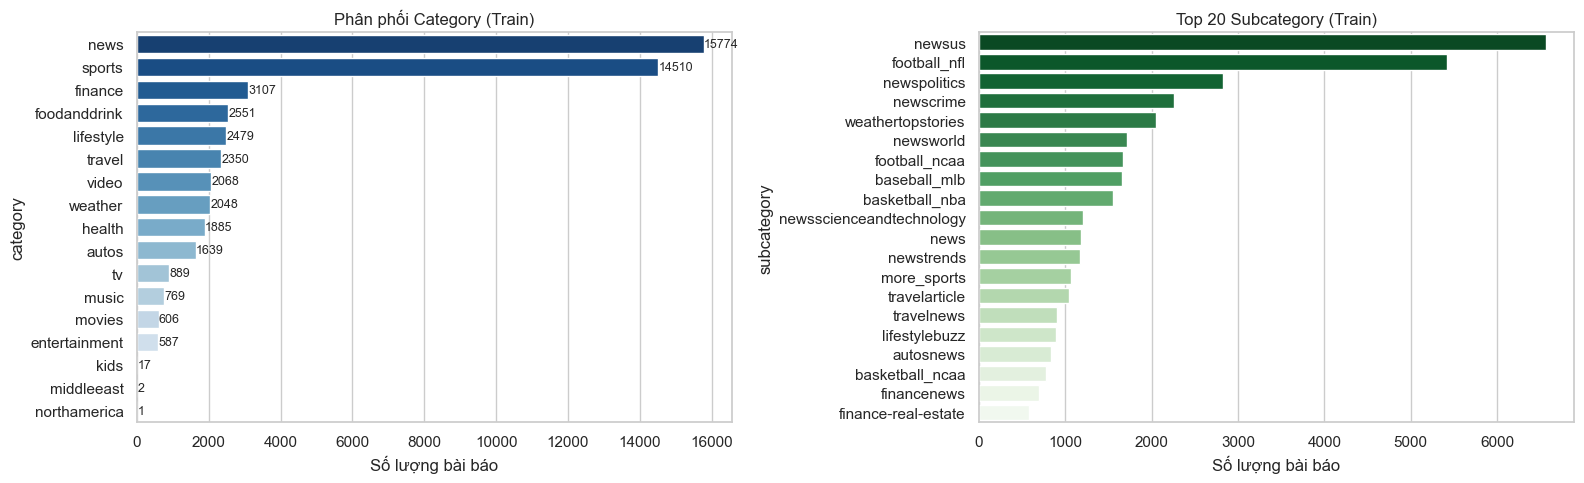


Tổng số category   : 17
Tổng số subcategory: 264


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Category
cat_counts = train_news['category'].value_counts()
sns.barplot(x=cat_counts.values, y=cat_counts.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('Phân phối Category (Train)')
axes[0].set_xlabel('Số lượng bài báo')
for i, v in enumerate(cat_counts.values):
    axes[0].text(v + 10, i, str(v), va='center', fontsize=9)

# Top 20 subcategory
sub_counts = train_news['subcategory'].value_counts().head(20)
sns.barplot(x=sub_counts.values, y=sub_counts.index, ax=axes[1], palette='Greens_r')
axes[1].set_title('Top 20 Subcategory (Train)')
axes[1].set_xlabel('Số lượng bài báo')

plt.tight_layout()
plt.show()

print(f"\nTổng số category   : {train_news['category'].nunique()}")
print(f"Tổng số subcategory: {train_news['subcategory'].nunique()}")

---
## 3. News — Độ dài Title & Abstract

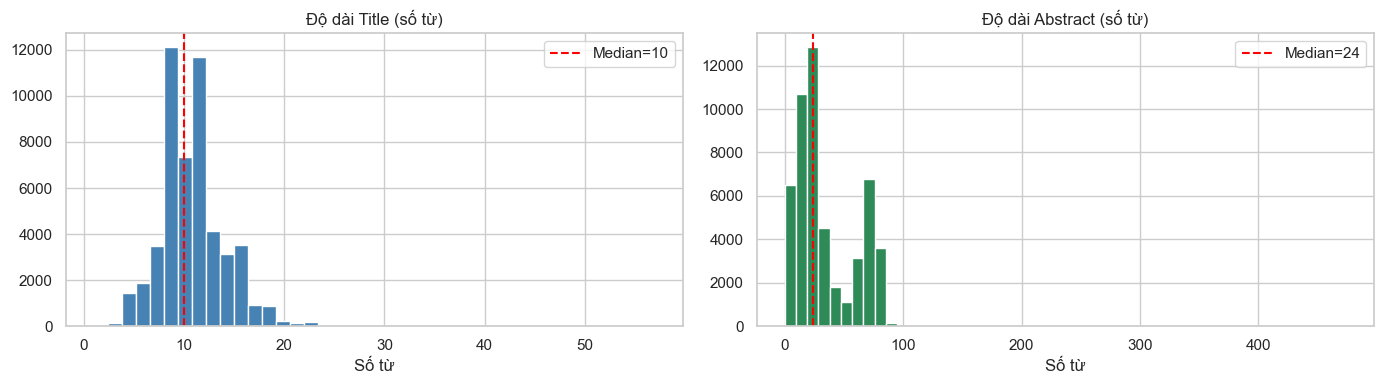

=== Title length ===
count    51282.0
mean        10.8
std          3.3
min          1.0
25%          9.0
50%         10.0
75%         13.0
max         57.0
Name: title_len, dtype: float64

=== Abstract length ===
count    51282.0
mean        34.3
std         26.5
min          0.0
25%         15.0
50%         24.0
75%         62.0
max        474.0
Name: abstract_len, dtype: float64

Abstract trống (0 từ): 2666 bài (5.2%)


In [6]:
train_news['title_len']    = train_news['title'].fillna('').str.split().str.len()
train_news['abstract_len'] = train_news['abstract'].fillna('').str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train_news['title_len'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(train_news['title_len'].median(), color='red', linestyle='--', label=f"Median={train_news['title_len'].median():.0f}")
axes[0].set_title('Độ dài Title (số từ)')
axes[0].set_xlabel('Số từ')
axes[0].legend()

axes[1].hist(train_news['abstract_len'], bins=50, color='seagreen', edgecolor='white')
axes[1].axvline(train_news['abstract_len'].median(), color='red', linestyle='--', label=f"Median={train_news['abstract_len'].median():.0f}")
axes[1].set_title('Độ dài Abstract (số từ)')
axes[1].set_xlabel('Số từ')
axes[1].legend()

plt.tight_layout()
plt.show()

print("=== Title length ===")
print(train_news['title_len'].describe().round(1))
print("\n=== Abstract length ===")
print(train_news['abstract_len'].describe().round(1))
print(f"\nAbstract trống (0 từ): {(train_news['abstract_len'] == 0).sum()} bài ({(train_news['abstract_len'] == 0).mean()*100:.1f}%)")

---
## 4. News — Entity Analysis

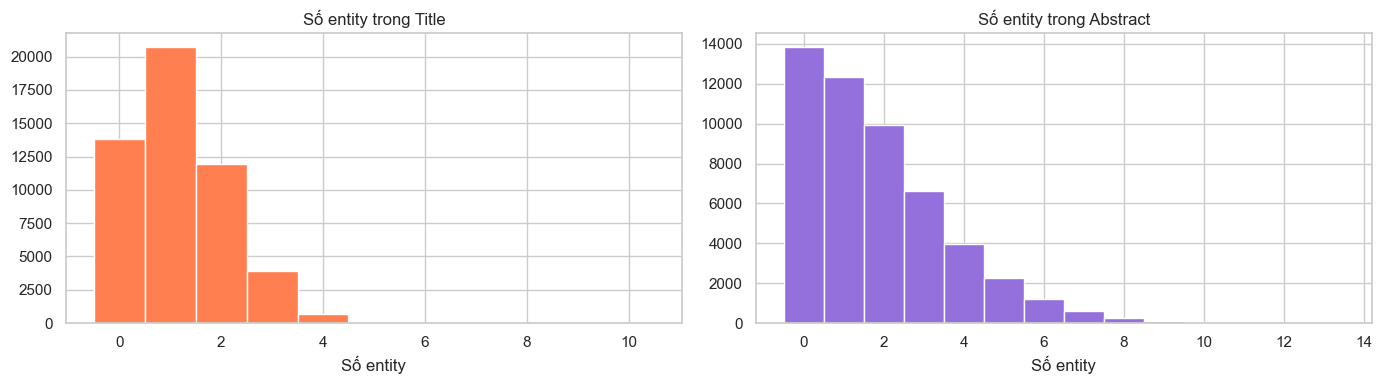

=== Entity Types ===
  Organization   : 38,694
  Location       : 37,184
  Person         : 34,807
  U              : 10,011
  Concept        : 6,613
  F              : 4,854
  N              : 4,604
  Media          : 3,883
  S              : 3,222
  W              : 2,331
  E              : 1,755
  L              : 1,538
  B              : 1,480
  H              : 1,164
  V              : 1,003
  K              : 785
  J              : 654
  Y              : 330
  R              : 192
  Q              : 60
  A              : 52
  I              : 41

Bài không có entity nào: 6798 (13.3%)


In [7]:
def parse_entities(entity_str):
    try:
        return json.loads(entity_str) if pd.notna(entity_str) else []
    except Exception:
        return []

train_news['title_ents_parsed'] = train_news['title_entities'].apply(parse_entities)
train_news['abs_ents_parsed']   = train_news['abstract_entities'].apply(parse_entities)
train_news['n_title_ents']      = train_news['title_ents_parsed'].str.len()
train_news['n_abs_ents']        = train_news['abs_ents_parsed'].str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(train_news['n_title_ents'], bins=range(0, 12), color='coral', edgecolor='white', align='left')
axes[0].set_title('Số entity trong Title')
axes[0].set_xlabel('Số entity')

axes[1].hist(train_news['n_abs_ents'], bins=range(0, 15), color='mediumpurple', edgecolor='white', align='left')
axes[1].set_title('Số entity trong Abstract')
axes[1].set_xlabel('Số entity')

plt.tight_layout()
plt.show()

# Entity types
all_ents = []
for ents in train_news['title_ents_parsed']:
    all_ents.extend(ents)
for ents in train_news['abs_ents_parsed']:
    all_ents.extend(ents)

type_counts = Counter(e.get('Type', 'UNK') for e in all_ents)
type_map = {'P': 'Person', 'G': 'Location', 'O': 'Organization', 'C': 'Concept', 'M': 'Media'}
print("=== Entity Types ===")
for k, v in sorted(type_counts.items(), key=lambda x: -x[1]):
    print(f"  {type_map.get(k, k):15s}: {v:,}")

print(f"\nBài không có entity nào: {((train_news['n_title_ents'] == 0) & (train_news['n_abs_ents'] == 0)).sum()} "
      f"({((train_news['n_title_ents'] == 0) & (train_news['n_abs_ents'] == 0)).mean()*100:.1f}%)")

---
## 5. Entity Embedding Coverage

In [8]:
# Load entity embedding IDs
entity_emb_ids = set()
with open(TRAIN_DIR / 'entity_embedding.vec', 'r') as f:
    for line in f:
        parts = line.strip().split('\t')
        if parts:
            entity_emb_ids.add(parts[0])

print(f"Số entity trong embedding file : {len(entity_emb_ids):,}")

# Entity IDs xuất hiện trong news
news_entity_ids = set()
for ents in train_news['title_ents_parsed']:
    for e in ents:
        news_entity_ids.add(e.get('WikidataId', ''))
for ents in train_news['abs_ents_parsed']:
    for e in ents:
        news_entity_ids.add(e.get('WikidataId', ''))
news_entity_ids.discard('')

covered = news_entity_ids & entity_emb_ids
coverage = len(covered) / len(news_entity_ids) * 100 if news_entity_ids else 0

print(f"Số entity unique trong news    : {len(news_entity_ids):,}")
print(f"Số entity có embedding         : {len(covered):,}")
print(f"Coverage                       : {coverage:.1f}%")

# Kiểm tra kích thước vector
with open(TRAIN_DIR / 'entity_embedding.vec', 'r') as f:
    first_line = f.readline().strip().split('\t')
vec_dim = len(first_line) - 1
print(f"\nKích thước entity embedding vector: {vec_dim}d")

Số entity trong embedding file : 26,904
Số entity unique trong news    : 27,759
Số entity có embedding         : 26,902
Coverage                       : 96.9%

Kích thước entity embedding vector: 100d


---
## 6. Behaviors — Tổng quan

In [9]:
train_beh.head(3)

,imp_id,user_id,time,history,impressions
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689-1 N35729-0
1,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678-0 N39317-0 N58114-0 N20495-0 N42977-0 N...
2,3,U73700,11/14/2019 7:01:48 AM,N10732 N25792 N7563 N21087 N41087 N5445 N60384...,N50014-0 N23877-0 N35389-0 N49712-0 N16844-0 N...


In [10]:
train_beh['history_len']  = train_beh['history'].fillna('').str.split().str.len()
train_beh['n_candidates'] = train_beh['impressions'].str.split().str.len()
train_beh['n_clicks']     = train_beh['impressions'].apply(
    lambda x: sum(1 for i in str(x).split() if i.endswith('-1')))
train_beh['ctr']          = train_beh['n_clicks'] / train_beh['n_candidates']
train_beh['time']         = pd.to_datetime(train_beh['time'])

print(f"Số impression logs : {len(train_beh):,}")
print(f"Số unique users    : {train_beh['user_id'].nunique():,}")
print(f"Khoảng thời gian   : {train_beh['time'].min()} → {train_beh['time'].max()}")
print(f"\nCold-start (history rỗng): {(train_beh['history_len'] == 0).sum():,} ({(train_beh['history_len'] == 0).mean()*100:.1f}%)")
print(f"CTR trung bình            : {train_beh['ctr'].mean()*100:.2f}%")

Số impression logs : 156,965
Số unique users    : 50,000
Khoảng thời gian   : 2019-11-09 00:00:19 → 2019-11-14 23:59:13

Cold-start (history rỗng): 3,238 (2.1%)
CTR trung bình            : 10.85%


---
## 7. Behaviors — Phân phối History & Impressions

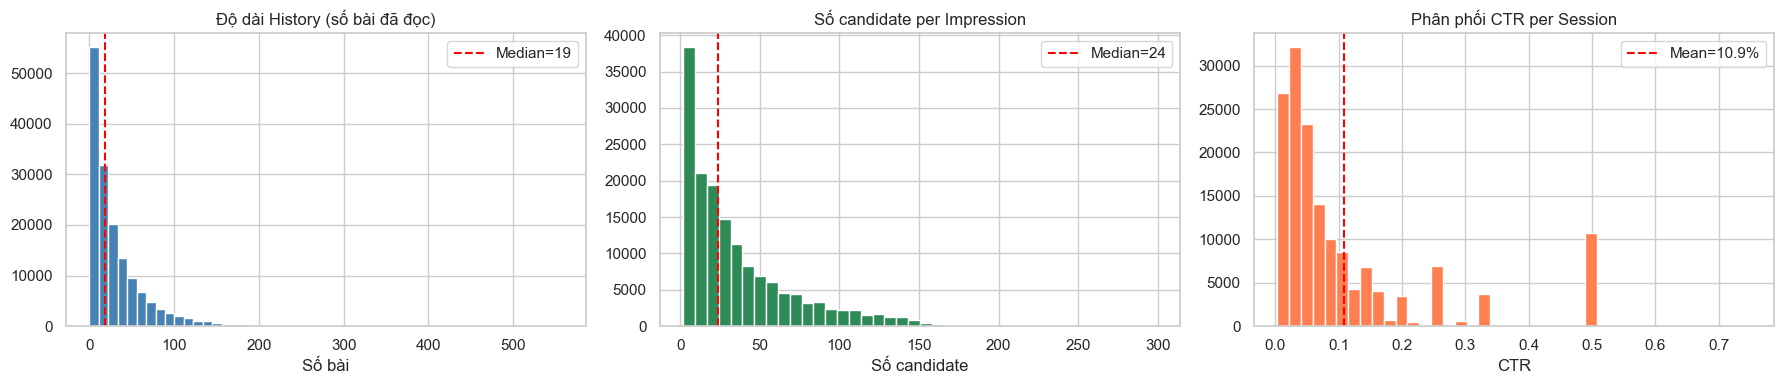

=== History length ===
count    156965.0
mean         32.5
std          40.3
min           0.0
25%           8.0
50%          19.0
75%          42.0
max         558.0
Name: history_len, dtype: float64

=== Số candidates ===
count    156965.0
mean         37.2
std          38.6
min           2.0
25%          10.0
50%          24.0
75%          51.0
max         299.0
Name: n_candidates, dtype: float64


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# History length
axes[0].hist(train_beh['history_len'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(train_beh['history_len'].median(), color='red', linestyle='--',
                label=f"Median={train_beh['history_len'].median():.0f}")
axes[0].set_title('Độ dài History (số bài đã đọc)')
axes[0].set_xlabel('Số bài')
axes[0].legend()

# Number of candidates per impression
axes[1].hist(train_beh['n_candidates'], bins=40, color='seagreen', edgecolor='white')
axes[1].axvline(train_beh['n_candidates'].median(), color='red', linestyle='--',
                label=f"Median={train_beh['n_candidates'].median():.0f}")
axes[1].set_title('Số candidate per Impression')
axes[1].set_xlabel('Số candidate')
axes[1].legend()

# CTR distribution
axes[2].hist(train_beh['ctr'].dropna(), bins=40, color='coral', edgecolor='white')
axes[2].axvline(train_beh['ctr'].mean(), color='red', linestyle='--',
                label=f"Mean={train_beh['ctr'].mean()*100:.1f}%")
axes[2].set_title('Phân phối CTR per Session')
axes[2].set_xlabel('CTR')
axes[2].legend()

plt.tight_layout()
plt.show()

print("=== History length ===")
print(train_beh['history_len'].describe().round(1))
print("\n=== Số candidates ===")
print(train_beh['n_candidates'].describe().round(1))

---
## 8. Behaviors — Hoạt động theo thời gian

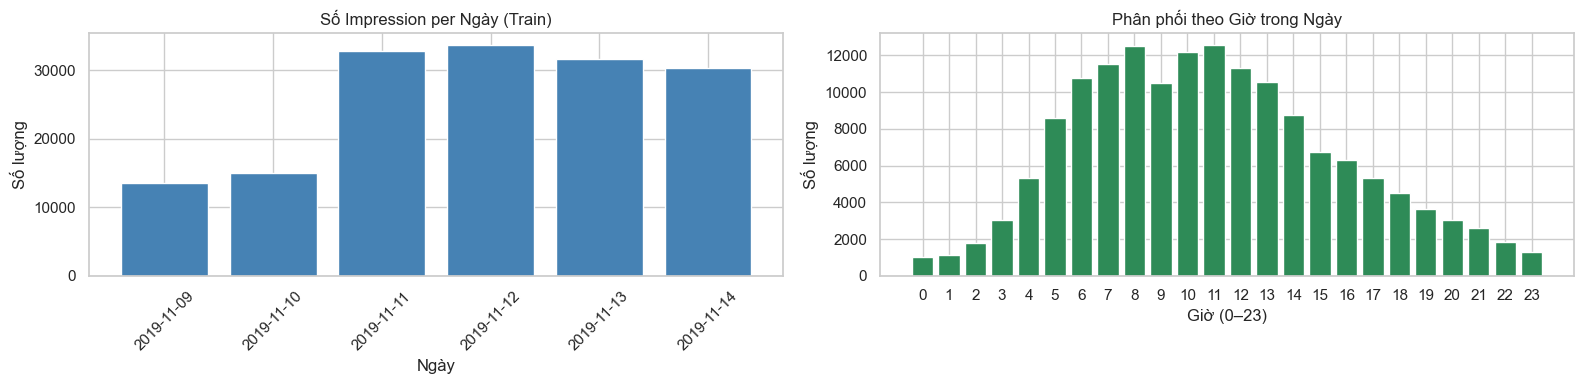

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Impressions per day
daily = train_beh.groupby(train_beh['time'].dt.date).size()
axes[0].bar(daily.index, daily.values, color='steelblue', width=0.8)
axes[0].set_title('Số Impression per Ngày (Train)')
axes[0].set_xlabel('Ngày')
axes[0].set_ylabel('Số lượng')
axes[0].tick_params(axis='x', rotation=45)

# Impressions per hour of day
hourly = train_beh.groupby(train_beh['time'].dt.hour).size()
axes[1].bar(hourly.index, hourly.values, color='seagreen', width=0.8)
axes[1].set_title('Phân phối theo Giờ trong Ngày')
axes[1].set_xlabel('Giờ (0–23)')
axes[1].set_ylabel('Số lượng')
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

---
## 9. Train / Dev Overlap

In [13]:
train_users = set(train_beh['user_id'])
dev_users   = set(dev_beh['user_id'])
train_news_ids = set(train_news['news_id'])
dev_news_ids   = set(dev_news['news_id'])

user_overlap = len(train_users & dev_users)
news_overlap = len(train_news_ids & dev_news_ids)

print("=== User Overlap ===")
print(f"  Train users : {len(train_users):,}")
print(f"  Dev users   : {len(dev_users):,}")
print(f"  Overlap     : {user_overlap:,} ({user_overlap/len(dev_users)*100:.1f}% of dev users)")

print("\n=== News Overlap ===")
print(f"  Train news  : {len(train_news_ids):,}")
print(f"  Dev news    : {len(dev_news_ids):,}")
print(f"  Overlap     : {news_overlap:,} ({news_overlap/len(dev_news_ids)*100:.1f}% of dev news)")

cold_start_dev_users = len(dev_users - train_users)
print(f"\n  User xuất hiện lần đầu trong dev (cold-start): {cold_start_dev_users:,} ({cold_start_dev_users/len(dev_users)*100:.1f}%)")

=== User Overlap ===
  Train users : 50,000
  Dev users   : 50,000
  Overlap     : 5,943 (11.9% of dev users)

=== News Overlap ===
  Train news  : 51,282
  Dev news    : 42,416
  Overlap     : 28,460 (67.1% of dev news)

  User xuất hiện lần đầu trong dev (cold-start): 44,057 (88.1%)


---
## 10. Tổng kết EDA — Quyết định kỹ thuật

In [14]:
summary = {
    "Tổng số bài báo (train)": len(train_news),
    "Số category": train_news['category'].nunique(),
    "Số subcategory": train_news['subcategory'].nunique(),
    "Abstract trống (%)": f"{(train_news['abstract_len']==0).mean()*100:.1f}%",
    "Median title length (words)": train_news['title_len'].median(),
    "Median abstract length (words)": train_news['abstract_len'].median(),
    "Entity embedding coverage (%)": f"{coverage:.1f}%",
    "Entity embedding dim": vec_dim,
    "Tổng impression logs": len(train_beh),
    "Unique users": train_beh['user_id'].nunique(),
    "Median history length": train_beh['history_len'].median(),
    "Cold-start users (%)": f"{(train_beh['history_len']==0).mean()*100:.1f}%",
    "CTR trung bình (%)": f"{train_beh['ctr'].mean()*100:.2f}%",
}

print("=" * 50)
print("  TỔNG KẾT EDA — MIND Small Dataset")
print("=" * 50)
for k, v in summary.items():
    print(f"  {k:<40}: {v}")

print("""
=== Quyết định kỹ thuật từ EDA ===
  1. Abstract trống nhiều       → ưu tiên dùng Title là text chính
  2. CTR thấp (~5-10%)          → dùng negative sampling hoặc weighted BCE loss
  3. History median ~50         → max_history=50 là reasonable
  4. Entity coverage cao        → nên dùng entity feature
  5. Cold-start users           → cần fallback: dùng category popularity
  6. Candidate list dài         → softmax normalization trên toàn candidate list
""")

  TỔNG KẾT EDA — MIND Small Dataset
  Tổng số bài báo (train)                 : 51282
  Số category                             : 17
  Số subcategory                          : 264
  Abstract trống (%)                      : 5.2%
  Median title length (words)             : 10.0
  Median abstract length (words)          : 24.0
  Entity embedding coverage (%)           : 96.9%
  Entity embedding dim                    : 100
  Tổng impression logs                    : 156965
  Unique users                            : 50000
  Median history length                   : 19.0
  Cold-start users (%)                    : 2.1%
  CTR trung bình (%)                      : 10.85%

=== Quyết định kỹ thuật từ EDA ===
  1. Abstract trống nhiều       → ưu tiên dùng Title là text chính
  2. CTR thấp (~5-10%)          → dùng negative sampling hoặc weighted BCE loss
  3. History median ~50         → max_history=50 là reasonable
  4. Entity coverage cao        → nên dùng entity feature
  5. Cold-start user